In [1]:
# 1. Install Tigramite and its optional independence test dependencies
!pip install tigramite dcor scikit-learn statsmodels

# 2. Install graphviz system-level dependency for advanced causal graph rendering
!apt-get install -y graphviz libgraphviz-dev
!pip install pygraphviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.7/314.7 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.6 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
The following additional packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgtk2.0-0
  libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk librsvg2-common
  libxcomposite1 libxdot4
Suggested packages:
  gvfs
The following NEW packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgraphviz-dev
  libgtk2.0-0 libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk
  librsvg2-common libxcomposite1 libxdot4
0 upgraded, 12 newly installed, 0 to remove and 3 not upgraded.
Need to get 2,496 kB of archives.
After this operation, 7,963 kB of additional 

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Tigramite imports
from tigramite import data_processing as pp
from tigramite.toymodels import structural_causal_processes as toys
from tigramite import plotting as tp
from tigramite.pcmci import PCMCI

# Conditional Independence Tests
from tigramite.independence_tests.parcorr import ParCorr
from tigramite.independence_tests.gpdc import GPDC
from tigramite.independence_tests.cmiknn import CMIknn

# 1. Set seed for reproducibility
np.random.seed(42)

# 2. Define structural causal process structural links
def lin_f(x):
    return x

links_coeffs = {
    0: [((0, -1), -0.7, lin_f), ((1, -1), -0.2, lin_f)],
    1: [((1, -1), -0.5, lin_f), ((3, -1), -0.8, lin_f)],
    2: [((2, -1), +0.35, lin_f), ((1, -2), -0.25, lin_f), ((3, -3), -0.6, lin_f)],
    3: [((3, -1), 0.9, lin_f)],
}

# 3. Generate data
T = 1000
data, true_parents = toys.structural_causal_process(links_coeffs, T=T)

# 4. Initialize Tigramite DataFrame DataFrame container
var_names = ['X0', 'X1', 'X2', 'X3']
df = pp.DataFrame(data, var_names=var_names)

print("Data generated successfully. Shape:", data.shape)

Data generated successfully. Shape: (1000, 4)



##
## Step 1: PC1 algorithm for selecting lagged conditions
##

Parameters:
independence test = par_corr
tau_min = 1
tau_max = 3
pc_alpha = [0.05]
max_conds_dim = None
max_combinations = 1



## Resulting lagged parent (super)sets:

    Variable X0 has 3 link(s):
        (X0 -1): max_pval = 0.00000, |min_val| =  0.522
        (X1 -1): max_pval = 0.00000, |min_val| =  0.213
        (X0 -3): max_pval = 0.03760, |min_val| =  0.066

    Variable X1 has 2 link(s):
        (X3 -1): max_pval = 0.00000, |min_val| =  0.551
        (X1 -1): max_pval = 0.00000, |min_val| =  0.192

    Variable X2 has 3 link(s):
        (X3 -3): max_pval = 0.00000, |min_val| =  0.471
        (X2 -1): max_pval = 0.00000, |min_val| =  0.387
        (X1 -2): max_pval = 0.00000, |min_val| =  0.260

    Variable X3 has 1 link(s):
        (X3 -1): max_pval = 0.00000, |min_val| =  0.670

##
## Step 2: MCI algorithm
##

Parameters:

independence test = par_corr
tau_min = 1
tau_max = 3
max_conds_py = None
max_conds_px = N

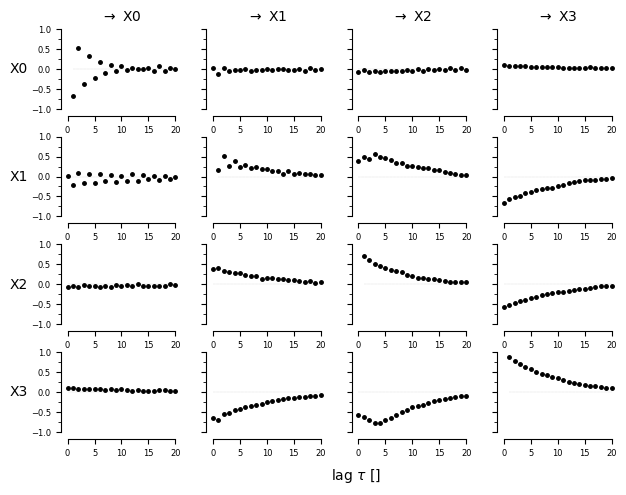


--- Plotting Time Series Graph ---


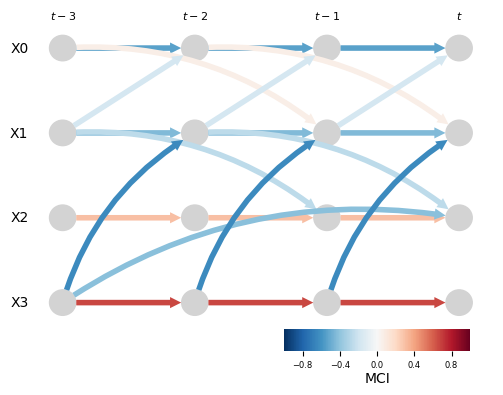


--- Plotting Summary Causal Graph ---


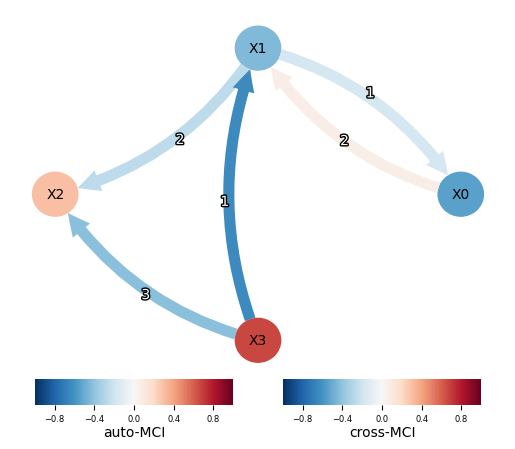

In [3]:
# 1. Initialize PCMCI object
pcmci = PCMCI(
    dataframe=df,
    cond_ind_test=ParCorr(),
    verbosity=1
)

# 2. Run the PCMCI algorithm
results = pcmci.run_pcmci(
    tau_min=1,
    tau_max=3,
    pc_alpha=0.05
)

# 3. Print out detected significant links
print("\n--- Significant Causal Links ---")
pcmci.print_significant_links(
    p_matrix=results['p_matrix'],
    val_matrix=results['val_matrix'],
    conf_matrix=results.get('conf_matrix', None),
    alpha_level=0.05
)

# 4. Inspect Lagged Dependencies (Lag Function Plot)
print("\n--- Plotting Lag Functions ---")
correlations = pcmci.get_lagged_dependencies(
    tau_max=20,
    val_only=True
)['val_matrix']

tp.plot_lagfuncs(
    val_matrix=correlations,
    setup_args={
        'var_names': var_names,
        'x_base': 5,
        'y_base': 0.5
    }
)
plt.show()

# 5. Plot Time Series Graph
print("\n--- Plotting Time Series Graph ---")
tp.plot_time_series_graph(
    figsize=(6, 4),
    val_matrix=results['val_matrix'],
    graph=results['graph'],
    var_names=var_names,
    link_colorbar_label='MCI'
)
plt.show()

# 6. Plot Process/Summary Causal Graph
print("\n--- Plotting Summary Causal Graph ---")
tp.plot_graph(
    val_matrix=results['val_matrix'],
    graph=results['graph'],
    var_names=var_names,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI'
)
plt.show()